# Objective
**The objective of this project is to predict customer churn using machine learning models and identify factors affecting customer retention.**

In [25]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import seaborn as sn
from sklearn import preprocessing

In [4]:
data=pd.read_csv('/content/drive/MyDrive/Datasets_datascience/Bank Customer Churn Prediction.csv')
data

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=data)

https://docs.google.com/spreadsheets/d/1gxVthRQCGjyk2sL2Bg5kQrAZlllsXMFpBxN_xsp_AEQ/edit#gid=0


In [7]:
data.shape

(10000, 12)

In [9]:
data.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [23]:
data.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [24]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.dtypes

,0
customer_id,int64
credit_score,int64
country,object
gender,object
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64


In [11]:
label_encoder=preprocessing.LabelEncoder()
data['country']=label_encoder.fit_transform(data['country'])
data['country'].unique()

array([0, 2, 1])

In [12]:
label_encoder=preprocessing.LabelEncoder()
data['gender']=label_encoder.fit_transform(data['gender'])
data['gender'].unique()

array([0, 1])

In [13]:
data.dtypes

,0
customer_id,int64
credit_score,int64
country,int64
gender,int64
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64


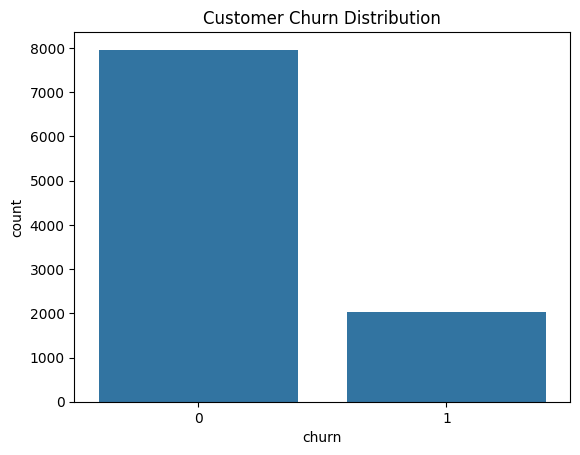

In [29]:
sn.countplot(x='churn', data=data)
plt.title('Customer Churn Distribution')
plt.show()

Text(0.5, 1.0, 'Customer Age')

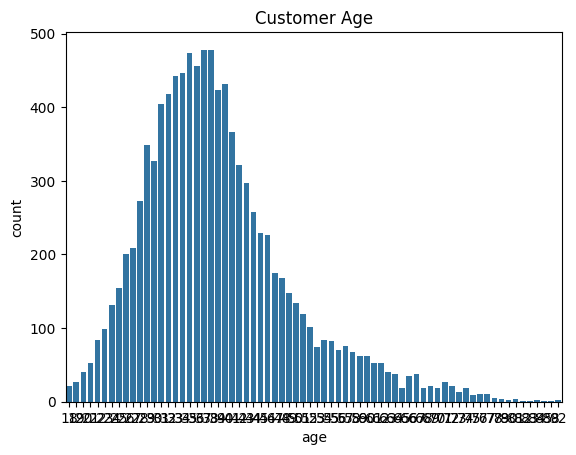

In [30]:
sn.countplot(data=data,x='age')
plt.title('Customer Age')

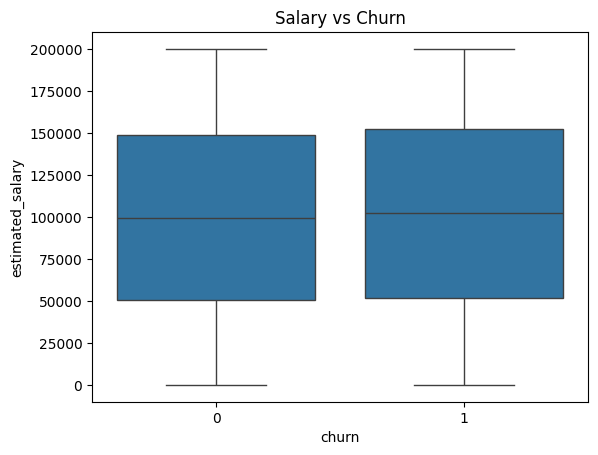

In [32]:
sn.boxplot(x='churn', y='estimated_salary', data=data)
plt.title('Salary vs Churn')
plt.show()

In [17]:
x=data.drop(['churn'],axis=1)
y=data['churn']

# Correct the order of variable assignment
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(7000, 11) (7000,)
(3000, 11) (3000,)


In [18]:
#Model
model=LogisticRegression()
model.fit(x_train,y_train)
LogisticRegression()
pred_y=model.predict(x_test)
pred_y

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, ..., 0, 0, 0])

In [19]:
model.score(x_test,y_test)

0.7786666666666666

In [20]:
cm=confusion_matrix(y_test,pred_y)
print(cm)

[[2302   71]
 [ 593   34]]


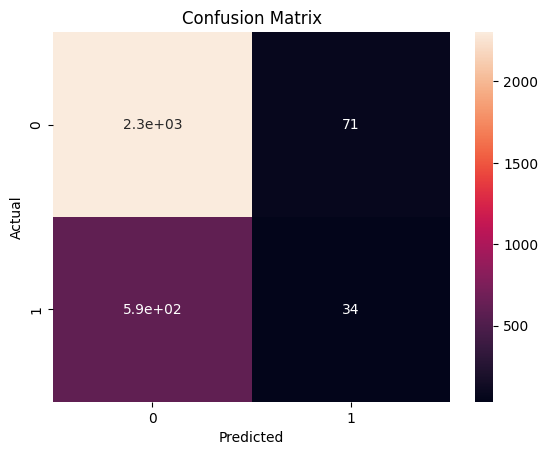

In [36]:
sn.heatmap(cm,annot=True)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

**Classification Report**

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2373
           1       1.00      1.00      1.00       627

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

